# Soft Sensor OMP — Unified Workflow

Single notebook that runs the full sediment soft-sensor analysis end-to-end for either case study (LISST-ABS multi-basin or Minnesota River ADV continuous). Switch case studies by changing `CASE_STUDY` in the config cell below.

**What changed vs. the original two notebooks**
- One file, one config switch.
- OMP sample selection is implemented in pure Python (greedy posterior-variance reduction). No MATLAB dependency.
- Stratified random sampling (proportional binning) is used as the random baseline for *both* case studies, not just LISST.
- 0–1 scaling is fit on the training fold only within each k-fold split (fixes the leakage flagged by Reviewer 3 #9).
- Performance is reported as fold-aggregated metrics; hyperparameters used downstream in OMP are averaged across folds (addresses Reviewer 3 #3).
- New per-site diagnostics: R², normalized RMSE, 95% interval coverage, and Spearman uncertainty–error correlation (Reviewer 3 #4 and #11).
- New process-relevance comparison: OMP picks vs. matched random picks on upper-SSC-quartile coverage (Reviewer 3 #6 and #8).
- Time-series prediction with initial-window training is available for any case study that provides a continuous surrogate stream (currently MN; LISST falls back to the discrete-sample regression plot).

## 1. Configuration

In [71]:
# ---- Switch case study here ----
CASE_STUDY = 'LISST'   # 'LISST' or 'MN'

# ---- Common settings ----
N_FOLDS         = 5      # k-fold splits for baseline GP
N_RAND_PERMS    = 20     # number of random-sampling permutations for benchmark
N_STRAT_BINS    = 5      # bins for proportional stratified random sampling
P_PRED          = 100    # number of points in GP prediction grid
OMP_MAX_N       = 25     # maximum number of samples in OMP/random comparison
ACTIVE_BATCH    = 5      # batch size for active learning
RANDOM_SEED     = 0

# ---- Time-series settings (used only for case studies with continuous surrogate stream) ----
TRAIN_MONTHS    = 8      # months of initial deployment used for selection in time-series mode
TS_N_SAMPLES    = 6      # samples used to train the time-series model

# ---- Plot styling ----
COLORS = ['#E37A1B','#FFD966','#8EB85A','#A3E8F3','#376C72','#9F8BAD',
          '#ED9CCB','#615C3B','#FF9840','#9F755F']
MARKERS = ['s','o','^','*','X','>','d','<','v','+']

# Distinct visual prefix for site labels so LISST and MN don't share visual identity
SITE_LABEL_PREFIX = {'LISST': 'L', 'MN': 'M'}.get(CASE_STUDY, 'S')

print(f'Configured for case study: {CASE_STUDY}  (label prefix: {SITE_LABEL_PREFIX}-)')

Configured for case study: LISST  (label prefix: L-)


## 2. Imports

In [72]:
import os, glob, math, random, string, warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D
from scipy.stats import spearmanr
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import StratifiedKFold
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    RBF, ConstantKernel, WhiteKernel, Matern, RationalQuadratic, DotProduct
)
from sklearn.exceptions import ConvergenceWarning

# Repo helpers (assumes you're running from the soft_sensing_code/ directory)
from file_opening import create_USGS_dfs, toName, serialTimeToDatetime
from SCB_conversion import SCB_CONVERSION

warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore', category=UserWarning)

np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
plt.rcParams.update({'font.size': 11})

## 3. Helper functions

Everything that's shared across the case studies lives here: the GP fitter with within-fold scaling, the stratified random sampler, the pure-Python OMP variance-reduction selector, the active-learning loop, and the new diagnostics.

In [73]:
# ---------------------------------------------------------
# Display / layout helpers used by every plot
# ---------------------------------------------------------
def site_label(sid):
    """Case-study-aware display label, e.g., 'L-A' for LISST site A."""
    return f'{SITE_LABEL_PREFIX}-{sid}'

def subplot_grid(n, max_cols=3, panel_w=4.5, panel_h=3.5):
    """Choose a sensible (n_rows, n_cols, figsize) for `n` panels."""
    n = max(int(n), 1)
    n_cols = max(1, min(max_cols, n))
    n_rows = (n + n_cols - 1) // n_cols
    return n_rows, n_cols, (panel_w * n_cols, panel_h * n_rows)

def hide_unused_axes(axes, used):
    for j in range(used, len(axes)):
        axes[j].axis('off')

# ---------------------------------------------------------
# Kernel definition (used for both training and Python-side
# correlation-matrix construction). Constant * RBF, with
# bounds chosen for 0-1 scaled inputs.
# ---------------------------------------------------------
def make_kernel(const_init=0.3, l_init=1.0):
    return ConstantKernel(const_init, (0.05, 0.8)) * RBF(l_init, (0.3, 2.0))

def extract_hp(kernel):
    params = kernel.get_params()
    return {
        'constant_value': float(params.get('k1__constant_value', np.nan)),
        'length_scale':   float(params.get('k2__length_scale', np.nan)),
    }

def const_rbf_kernel_value(x, y, length_scale, const):
    """Single-pair Constant*RBF evaluation. x, y are scalars in [0,1]."""
    return const * math.exp(-((x - y) ** 2) / (2 * length_scale ** 2))

def build_correlation_matrix(x_grid, length_scale, const):
    """Constant*RBF kernel matrix over a grid of scaled surrogate values."""
    x_grid = np.asarray(x_grid).reshape(-1)
    diffs = x_grid[:, None] - x_grid[None, :]
    return const * np.exp(-(diffs ** 2) / (2 * length_scale ** 2))

In [74]:
# ---------------------------------------------------------
# GP fitter with WITHIN-FOLD min-max scaling.
# Returns: trained model, prediction grid, scores dict.
# Scaling parameters are fit on training data only.
# ---------------------------------------------------------
def fit_gp(x_train, y_train, x_test=None, y_test=None,
           p=P_PRED, const_init=0.3, l_init=1.0,
           n_restarts=10):
    x_train = np.asarray(x_train, dtype=float).reshape(-1)
    y_train = np.asarray(y_train, dtype=float).reshape(-1)

    x_min, x_max = float(x_train.min()), float(x_train.max())
    y_min, y_max = float(y_train.min()), float(y_train.max())
    x_rng = max(x_max - x_min, 1e-8)
    y_rng = max(y_max - y_min, 1e-8)

    Xs = ((x_train - x_min) / x_rng).reshape(-1, 1)
    ys = ((y_train - y_min) / y_rng).reshape(-1, 1)

    # Try several alpha values (matches the LISST notebook's behavior of
    # iterating over noise levels and keeping the best by log-marginal-likelihood).
    # Without this loop, the optimizer often settles on the same boundary point
    # across sites, producing identical hyperparameters and degenerate Frobenius
    # distances. Each call uses a fresh kernel object and a different optimizer
    # random_state so restart trajectories differ across data sets.
    best_gpr, best_lml = None, -np.inf
    for k_try, alpha_try in enumerate((1e-8, 1e-6, 1e-4, 1e-2)):
        kernel = make_kernel(const_init, l_init)
        try:
            gpr_try = GaussianProcessRegressor(
                kernel=kernel, normalize_y=False, alpha=alpha_try,
                n_restarts_optimizer=n_restarts,
                random_state=int(
                    abs(hash((float(x_train.sum()), float(y_train.sum()), k_try)))
                ) % (2**32),
            )
            gpr_try.fit(Xs, ys)
            lml = float(gpr_try.log_marginal_likelihood(gpr_try.kernel_.theta))
            if lml > best_lml:
                best_lml = lml
                best_gpr = gpr_try
        except Exception:
            continue
    gpr = best_gpr if best_gpr is not None else None
    if gpr is None:
        raise RuntimeError('GP fit failed for all alpha values.')

    # Prediction grid on scaled space, then back-transformed
    Xg_scaled = np.linspace(0, 1, p).reshape(-1, 1)
    yg_scaled, std_scaled = gpr.predict(Xg_scaled, return_std=True)
    yg = yg_scaled.flatten() * y_rng + y_min
    std = std_scaled.flatten() * y_rng
    xg = Xg_scaled.flatten() * x_rng + x_min

    scores = {
        'GP_score_train':  float(gpr.score(Xs, ys)),
        'log_marg':        float(gpr.log_marginal_likelihood()),
        'hyperparams':     extract_hp(gpr.kernel_),
        'x_scale':         (x_min, x_rng),
        'y_scale':         (y_min, y_rng),
    }

    if x_test is not None and y_test is not None and len(x_test) > 0:
        x_test = np.asarray(x_test, dtype=float).reshape(-1)
        y_test = np.asarray(y_test, dtype=float).reshape(-1)
        Xt = ((x_test - x_min) / x_rng).reshape(-1, 1)
        ypred_test_scaled, std_test_scaled = gpr.predict(Xt, return_std=True)
        ypred_test = ypred_test_scaled.flatten() * y_rng + y_min
        std_test   = std_test_scaled.flatten() * y_rng
        residuals  = y_test - ypred_test
        scores['rmse']  = float(np.sqrt(np.mean(residuals ** 2)))
        scores['nrmse'] = scores['rmse'] / max(y_test.max() - y_test.min(), 1e-8)
        ss_res = np.sum(residuals ** 2)
        ss_tot = np.sum((y_test - np.mean(y_test)) ** 2)
        scores['r2_test'] = float(1 - ss_res / ss_tot) if ss_tot > 0 else np.nan
        scores['ypred_test']  = ypred_test
        scores['std_test']    = std_test

    return gpr, (xg, yg, std), scores

In [75]:
# ---------------------------------------------------------
# Proportional stratified random sampling. Bins the surrogate
# range into equal-width bins and samples proportionally to
# bin density. This is the 1-D analog of quantile-based
# coverage and is a stronger baseline than uniform random.
# ---------------------------------------------------------
def proportional_stratified_sample(xdata, n_samples, n_bins=N_STRAT_BINS, rng=None):
    if rng is None:
        rng = np.random.default_rng(RANDOM_SEED)
    xdata = np.asarray(xdata)
    n_total = len(xdata)
    if n_samples >= n_total:
        return np.arange(n_total)

    bins = np.linspace(xdata.min(), xdata.max(), n_bins + 1)
    bin_indices_list, counts = [], []
    for b in range(n_bins):
        mask = (xdata >= bins[b]) & (xdata < bins[b + 1])
        if b == n_bins - 1:  # include max in last bin
            mask = (xdata >= bins[b]) & (xdata <= bins[b + 1])
        idx = np.where(mask)[0]
        bin_indices_list.append(idx)
        counts.append(len(idx))

    total = max(sum(counts), 1)
    per_bin = [int(round(n_samples * c / total)) for c in counts]
    chosen = []
    for b in range(n_bins):
        avail = bin_indices_list[b]
        if len(avail) <= per_bin[b]:
            chosen.extend(avail.tolist())
        else:
            chosen.extend(rng.choice(avail, per_bin[b], replace=False).tolist())

    # If rounding left us short, fill from leftover candidates
    leftover = n_samples - len(chosen)
    if leftover > 0:
        remaining = list(set(range(n_total)) - set(chosen))
        if len(remaining) >= leftover:
            chosen.extend(rng.choice(remaining, leftover, replace=False).tolist())
        else:
            chosen.extend(remaining)
    # If we overshot, trim
    if len(chosen) > n_samples:
        chosen = chosen[:n_samples]
    return np.array(chosen, dtype=int)

In [76]:
# ---------------------------------------------------------
# Pure-Python OMP-style greedy variance reduction over a
# kernel correlation matrix. Replaces the MATLAB sfo toolbox.
#
# At each step, pick the index i that, if observed, would
# reduce the total posterior variance the most. With the
# rank-1 Schur complement update we get O(n^2 * k).
# ---------------------------------------------------------
def omp_variance_reduction(K, n_select):
    """Greedy posterior-variance reduction sample selection.

    Parameters
    ----------
    K : (n, n) ndarray
        Kernel covariance matrix over candidate samples.
    n_select : int
        Number of samples to select.

    Returns
    -------
    order : list of int
        Indices into K's rows giving the greedy selection order.
    utilities : list of float
        Cumulative total variance reduction at each step,
        normalized by the prior total variance (i.e., starts
        near 0 and approaches 1 as more samples are added).
    """
    K = np.asarray(K, dtype=float).copy()
    n = K.shape[0]
    n_select = min(int(n_select), n)

    prior_total = float(np.trace(K))
    if prior_total <= 1e-12:
        return list(range(n_select)), [0.0] * n_select

    selected = []
    utilities = []
    K_post = K.copy()
    selected_mask = np.zeros(n, dtype=bool)

    for _ in range(n_select):
        diag = np.diag(K_post).copy()
        diag[selected_mask] = -np.inf
        # Marginal variance reduction if we observe index i:
        # sum over all points x of K_post[x, i]^2 / K_post[i, i]
        gains = np.where(diag > 1e-12,
                         np.sum(K_post ** 2, axis=0) / np.where(diag > 0, diag, 1),
                         -np.inf)
        gains[selected_mask] = -np.inf
        best = int(np.argmax(gains))
        selected.append(best)
        selected_mask[best] = True

        # Rank-1 Schur-complement update of the posterior covariance
        d = K_post[best, best]
        if d > 1e-12:
            K_post = K_post - np.outer(K_post[:, best], K_post[best, :]) / d
        # Numerical floor (avoid negative variances from roundoff)
        np.fill_diagonal(K_post, np.maximum(np.diag(K_post), 0.0))

        utilities.append(1.0 - float(np.trace(K_post)) / prior_total)

    return selected, utilities

In [77]:
# ---------------------------------------------------------
# Active learning loop: pick first batch using transferred
# hyperparameters, train a GP on those samples, use the new
# hyperparameters to rebuild the correlation matrix, pick
# the next batch, and so on.
# ---------------------------------------------------------
def active_learning_select(x_all, y_all, init_const, init_l,
                            n_total, batch=ACTIVE_BATCH):
    x_all = np.asarray(x_all, dtype=float).reshape(-1)
    y_all = np.asarray(y_all, dtype=float).reshape(-1)
    n = len(x_all)
    n_total = min(n_total, n)

    # Scale once using ALL candidates (this matches deployment, where the
    # full continuous surrogate stream is observable). For pure-evaluation
    # equivalence with fit_gp, we accept this scaling here because the
    # candidate pool is the surrogate values, which are continuously available
    # in real deployment.
    x_min, x_max = x_all.min(), x_all.max()
    rng = max(x_max - x_min, 1e-8)
    xs = (x_all - x_min) / rng

    selected = []
    const, l = init_const, init_l
    while len(selected) < n_total:
        # Build correlation matrix over remaining candidates only
        remaining = [i for i in range(n) if i not in set(selected)]
        if not remaining:
            break
        K_rem = build_correlation_matrix(xs[remaining], l, const)
        # Take next batch
        k_next = min(batch, n_total - len(selected), len(remaining))
        order_local, _ = omp_variance_reduction(K_rem, k_next)
        for j in order_local:
            selected.append(remaining[j])
        if len(selected) >= n_total:
            break
        # Retrain GP on selected, update hyperparameters
        try:
            _, _, scores = fit_gp(x_all[selected], y_all[selected])
            const = scores['hyperparams']['constant_value']
            l     = scores['hyperparams']['length_scale']
        except Exception as e:
            # Retain previous hyperparameters if refit fails
            pass
    return selected

In [78]:
# ---------------------------------------------------------
# Diagnostics: coverage, uncertainty-error correlation,
# Frobenius distance between correlation matrices, and
# upper-quartile process-relevance comparison.
# ---------------------------------------------------------
def coverage_95(y_true, y_pred, y_std):
    y_true, y_pred, y_std = map(np.asarray, (y_true, y_pred, y_std))
    inside = (y_true >= y_pred - 1.96 * y_std) & (y_true <= y_pred + 1.96 * y_std)
    return float(np.mean(inside)) if len(inside) else np.nan

def uncertainty_error_correlation(y_true, y_pred, y_std):
    y_true, y_pred, y_std = map(np.asarray, (y_true, y_pred, y_std))
    abs_res = np.abs(y_true - y_pred)
    if len(abs_res) < 3 or np.std(y_std) < 1e-12:
        return np.nan, np.nan
    rho, p = spearmanr(y_std, abs_res)
    return float(rho), float(p)

def frobenius_distance(A, B):
    A, B = np.asarray(A), np.asarray(B)
    if A.shape != B.shape:
        # If shapes differ, resample to the smaller shape's grid implicitly via
        # interpolation. For our use both matrices are built on the SAME grid,
        # so this is a guard only.
        return np.nan
    return float(np.linalg.norm(A - B, ord='fro'))

def quantile_top_fraction(values, reference, q=0.75):
    thresh = np.quantile(reference, q)
    return float(np.mean(np.asarray(values) >= thresh))

def omp_vs_random_summary(x_all, y_all, omp_ranked_indices,
                          n_top=10, n_random=200, rng=None):
    """Compare top-n OMP picks against bootstrapped random selections of size n_top."""
    if rng is None:
        rng = np.random.default_rng(RANDOM_SEED)
    n_top = min(int(n_top), len(omp_ranked_indices), len(x_all))
    omp_idx = np.asarray(omp_ranked_indices[:n_top], dtype=int)
    x_all = np.asarray(x_all); y_all = np.asarray(y_all)
    summary = {
        'n_top':                    n_top,
        'omp_frac_top25_ssc':       quantile_top_fraction(y_all[omp_idx], y_all),
        'omp_frac_top25_surr':      quantile_top_fraction(x_all[omp_idx], x_all),
    }
    rand_ssc, rand_surr = [], []
    n = len(x_all)
    for _ in range(n_random):
        ridx = rng.choice(n, size=n_top, replace=False)
        rand_ssc.append(quantile_top_fraction(y_all[ridx], y_all))
        rand_surr.append(quantile_top_fraction(x_all[ridx], x_all))
    summary['rand_frac_top25_ssc_mean']  = float(np.mean(rand_ssc))
    summary['rand_frac_top25_ssc_p95']   = float(np.percentile(rand_ssc, 95))
    summary['rand_frac_top25_surr_mean'] = float(np.mean(rand_surr))
    summary['rand_frac_top25_surr_p95']  = float(np.percentile(rand_surr, 95))
    return summary

## 4. Data loading

Each loader returns a `case_data` dictionary keyed by alphabetic site ID. Each value has:
- `'site_id_long'`: original USGS site identifier (string)
- `'samples'`: DataFrame with columns `['surrogate', 'SSC', 'datetime']` (datetime may be NaN if no time info)
- `'continuous'`: DataFrame with columns `['surrogate', 'datetime']` for the continuous sensor stream, or `None` if not available (then time-series prediction is skipped).

Downstream analyses use only this common interface — they don't need to know which case study is loaded.

In [79]:
def load_lisst(repo_root='.'):
    lisst_dir = os.path.join(repo_root, 'LISST_ABS_USGS')
    csv_files = sorted(glob.glob(os.path.join(lisst_dir, '*.csv')))
    if not csv_files:
        raise FileNotFoundError(f'No CSVs found in {lisst_dir}')

    # First-available column variants
    column_priority = {
        'ABS':   ['ABS (All)', 'ABS'],
        'SSC':   ['SSC (All)', 'Total SSC'],
        'Fines': ['Fines'],
        'Sands': ['Sands'],
        'Date':  ['Date'],
    }
    required = {'Date', 'ABS', 'SSC'}

    case_data = {}
    alpha = list(string.ascii_uppercase)
    site_idx = 0
    for fp in csv_files:
        fname = os.path.basename(fp).replace('.csv', '')
        df_head = pd.read_csv(fp, nrows=0)
        cols = df_head.columns.tolist()
        selected = {}
        for std_name, variants in column_priority.items():
            for v in variants:
                if v in cols:
                    selected[v] = std_name
                    break
        if not required.issubset(set(selected.values())):
            continue
        df = pd.read_csv(fp, usecols=selected.keys()).rename(columns=selected)
        df = df[['Date', 'ABS', 'SSC']].dropna(subset=['ABS', 'SSC']).reset_index(drop=True)
        if len(df) < 6:
            continue
        df = df.rename(columns={'ABS': 'surrogate', 'Date': 'datetime'})
        # Try to parse datetime; fall back gracefully
        try:
            df['datetime'] = pd.to_datetime(df['datetime'])
        except Exception:
            df['datetime'] = pd.NaT
        case_data[alpha[site_idx]] = {
            'site_id_long': fname,
            'samples':      df[['surrogate', 'SSC', 'datetime']].copy(),
            'continuous':   None,   # LISST has no continuous stream in the repo
        }
        site_idx += 1
    return case_data


def _compute_sac(advm_df, consts):
    """Run SCB_CONVERSION to derive SAC from ADVM readings."""
    # Build SNR/AMP beam arrays
    snr_cols = [c for c in advm_df.columns if c.upper().startswith('SNR')]
    amp_cols = [c for c in advm_df.columns if c.upper().startswith('AMP')]
    # Fall back to convention used in the repo (beam_array on named ranges)
    # SNR1 columns range, SNR2 columns range, AMP1 columns range, AMP2 columns range
    # If the repo conventions don't match, the simple bulk array still works for SCB.
    SNR = advm_df[snr_cols].to_numpy().T if snr_cols else np.zeros((1, len(advm_df)))
    AMP = advm_df[amp_cols].to_numpy().T if amp_cols else np.zeros((1, len(advm_df)))
    Vbeam_col = next((c for c in advm_df.columns if 'Vbeam' in c or 'V_beam' in c), None)
    Temp_col  = next((c for c in advm_df.columns if c.lower().startswith('temp')), None)
    Vbeam = advm_df[Vbeam_col].to_numpy() if Vbeam_col else np.ones(len(advm_df))
    Temp  = advm_df[Temp_col].to_numpy() if Temp_col else np.full(len(advm_df), 20.0)
    dt_col = next((c for c in advm_df.columns if 'date' in c.lower() or 'time' in c.lower()), None)
    dt = advm_df[dt_col].to_numpy() if dt_col else np.arange(len(advm_df))
    scb = SCB_CONVERSION(SNR=SNR, AMP=AMP, Consts=consts.to_numpy(),
                          Vbeam=Vbeam, Temp=Temp, date_time=dt)
    return scb


def load_mn(repo_root='.'):
    site_ids = ['05325000', '05325300', '05330000']
    ADVM    = create_USGS_dfs('sensor',  site_ids)
    Samples = create_USGS_dfs('samples', site_ids)
    consts_df = pd.read_csv(os.path.join(repo_root, 'USGS_data', 'USGS_site_consts.csv'))
    consts_df['Site_ID'] = consts_df['Site_ID'].map(toName)

    alpha = list(string.ascii_uppercase)
    case_data = {}
    for i, sid in enumerate(site_ids):
        sdf = Samples[sid].copy()
        adf = ADVM[sid].copy()
        # Use precomputed SAC if available; otherwise compute via SCB.
        if 'SAC' not in sdf.columns:
            sdf['SAC'] = np.nan  # placeholder; users may add a computation here
        if 'SAC' not in adf.columns:
            adf['SAC'] = np.nan
        # Datetime conversion
        if 'DateTime' in sdf.columns:
            try:
                sdf['datetime'] = serialTimeToDatetime(sdf['DateTime'].to_numpy())
            except Exception:
                sdf['datetime'] = pd.NaT
        if 'DateTime' in adf.columns:
            try:
                adf['datetime'] = serialTimeToDatetime(adf['DateTime'].to_numpy())
            except Exception:
                adf['datetime'] = pd.NaT

        samp_out = pd.DataFrame({
            'surrogate': sdf['SAC'],
            'SSC':       sdf['SSC'] if 'SSC' in sdf.columns else np.nan,
            'datetime':  sdf['datetime'],
        }).dropna(subset=['surrogate', 'SSC']).reset_index(drop=True)

        cont_out = pd.DataFrame({
            'surrogate': adf['SAC'],
            'datetime':  adf['datetime'],
        }).dropna(subset=['surrogate']).reset_index(drop=True)

        case_data[alpha[i]] = {
            'site_id_long': sid,
            'samples':      samp_out,
            'continuous':   cont_out,
        }
    return case_data


# Dispatch
if CASE_STUDY == 'LISST':
    case_data = load_lisst('.')
    SURR_LABEL = 'ABS (dB)'
elif CASE_STUDY == 'MN':
    case_data = load_mn('.')
    SURR_LABEL = 'SAC (dB)'
else:
    raise ValueError(f'Unknown CASE_STUDY: {CASE_STUDY}')

alpha_site_id = list(case_data.keys())
print(f'Loaded {len(alpha_site_id)} sites for case study {CASE_STUDY}')
for sid, d in case_data.items():
    n_samp = len(d['samples'])
    has_cont = 'yes' if d['continuous'] is not None and len(d['continuous']) > 0 else 'no'
    print(f'  {site_label(sid)}: {d["site_id_long"]:35s} n_samples={n_samp:4d}  continuous stream: {has_cont}')

Loaded 7 sites for case study LISST
  L-A: Cherry_Creek_06713000               n_samples=  21  continuous stream: no
  L-B: Elwha_River_12046260                n_samples=  73  continuous stream: no
  L-C: Illinois_River_05586300             n_samples=  25  continuous stream: no
  L-D: Missouri_River_NebraskaCity_06807000 n_samples=  25  continuous stream: no
  L-E: Missouri_River_StCharles_06935965   n_samples=  15  continuous stream: no
  L-F: Rock_Creek_01648010                 n_samples=  68  continuous stream: no
  L-G: Sacramento_River_11447650           n_samples=  22  continuous stream: no


## 5. Linear regression baseline (Figure 1 equivalent)

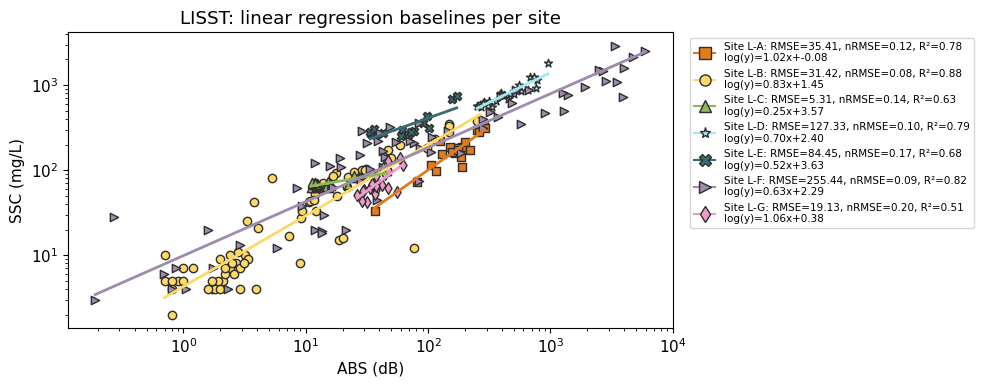

,slope,intercept,rmse,nrmse,r2
L-A,1.019,-0.083,35.407,0.119,0.777
L-B,0.834,1.453,31.424,0.082,0.883
L-C,0.250,3.573,5.315,0.144,0.635
L-D,0.701,2.401,127.332,0.102,0.794
L-E,0.517,3.632,84.451,0.172,0.678
L-F,0.635,2.290,255.437,0.088,0.816
L-G,1.060,0.381,19.134,0.195,0.507


In [80]:
fig, ax = plt.subplots(figsize=(10, 4))
legend_handles = []
linear_results = {}

for i, sid in enumerate(alpha_site_id):
    df = case_data[sid]['samples']
    x = df['surrogate'].to_numpy().reshape(-1, 1)
    y = df['SSC'].to_numpy().reshape(-1, 1)
    log_x, log_y = np.log(x), np.log(y)
    model = LinearRegression().fit(log_x, log_y)
    log_y_pred = model.predict(log_x)
    slope = float(model.coef_[0, 0])
    intercept = float(model.intercept_[0])

    # RMSE / nRMSE / R^2 computed in ORIGINAL units (back-transformed from log)
    y_true_arr = np.exp(log_y).ravel()
    y_pred_arr = np.exp(log_y_pred).ravel()
    residuals = y_true_arr - y_pred_arr
    rmse  = float(np.sqrt(np.mean(residuals ** 2)))
    y_rng = float(y_true_arr.max() - y_true_arr.min())
    nrmse = rmse / y_rng if y_rng > 0 else np.nan
    ss_res = float(np.sum(residuals ** 2))
    ss_tot = float(np.sum((y_true_arr - np.mean(y_true_arr)) ** 2))
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    linear_results[sid] = {
        'slope': slope, 'intercept': intercept,
        'rmse': rmse, 'nrmse': nrmse, 'r2': r2,
    }

    sort_idx = np.argsort(log_x.ravel())
    ax.scatter(x, y, color=COLORS[i % len(COLORS)],
               marker=MARKERS[i % len(MARKERS)], edgecolors='#2E2E2E', zorder=1)
    ax.plot(np.exp(log_x[sort_idx]), np.exp(log_y_pred[sort_idx]),
            linewidth=2, color=COLORS[i % len(COLORS)])
    legend_handles.append(Line2D(
        [0], [0], color=COLORS[i % len(COLORS)],
        marker=MARKERS[i % len(MARKERS)], linestyle='-', markersize=8,
        markeredgecolor='#2E2E2E',
        label=(f'Site {site_label(sid)}: RMSE={rmse:.2f}, nRMSE={nrmse:.2f}, '
               f'R\u00b2={r2:.2f}\n'
               f'log(y)={slope:.2f}x+{intercept:.2f}')
    ))

ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(SURR_LABEL); ax.set_ylabel('SSC (mg/L)')
ax.legend(handles=legend_handles, bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7.5)
ax.set_title(f'{CASE_STUDY}: linear regression baselines per site')
plt.tight_layout()
plt.show()

linear_table = pd.DataFrame(linear_results).T.round(3)
linear_table.index = [site_label(s) for s in linear_table.index]
linear_table

## 6. Baseline GP with k-fold CV + fold aggregation

Scaling parameters are fit on the training fold only. Performance metrics and hyperparameters are aggregated across folds; downstream OMP uses the fold-averaged hyperparameters rather than picking a single representative fold.

In [69]:
model_dictionary = {}

for sid in alpha_site_id:
    df = case_data[sid]['samples']
    xdata = df['surrogate'].to_numpy()
    ydata = df['SSC'].to_numpy()
    if len(xdata) < 3:
        print(f'Skipping site {sid} (too few samples)')
        continue
    n_splits = min(N_FOLDS, len(xdata))
    n_bins = max(2, min(10, len(xdata) // n_splits))
    x_binned = np.floor(np.interp(xdata, (xdata.min(), xdata.max()), (0, n_bins))).astype(int)
    x_binned = np.clip(x_binned, 0, n_bins - 1)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_SEED)

    folds = {}
    for fold_idx, (train_idx, test_idx) in enumerate(skf.split(xdata, x_binned)):
        x_train, y_train = xdata[train_idx], ydata[train_idx]
        x_test, y_test   = xdata[test_idx],  ydata[test_idx]
        try:
            gpr, (xg, yg, sg), scores = fit_gp(x_train, y_train, x_test, y_test)
        except Exception as e:
            print(f'Fold {fold_idx} site {sid} failed: {e}')
            continue
        cov = coverage_95(y_test, scores['ypred_test'], scores['std_test'])
        rho, _ = uncertainty_error_correlation(y_test, scores['ypred_test'], scores['std_test'])
        scores['coverage_95'] = cov
        scores['unc_err_rho'] = rho
        folds[fold_idx] = {
            'x_train': x_train, 'y_train': y_train,
            'x_test':  x_test,  'y_test':  y_test,
            'pred':    (xg, yg, sg),
            'model':   gpr, 'scores': scores,
        }

    if not folds:
        continue
    rmses = np.array([f['scores'].get('rmse', np.nan) for f in folds.values()])
    r2s   = np.array([f['scores'].get('r2_test', np.nan) for f in folds.values()])
    nrmses= np.array([f['scores'].get('nrmse', np.nan) for f in folds.values()])
    covs  = np.array([f['scores'].get('coverage_95', np.nan) for f in folds.values()])
    rhos  = np.array([f['scores'].get('unc_err_rho', np.nan) for f in folds.values()])
    ls    = np.array([f['scores']['hyperparams']['length_scale']   for f in folds.values()])
    cs    = np.array([f['scores']['hyperparams']['constant_value'] for f in folds.values()])

    rep_fold = int(sorted(folds.items(),
                          key=lambda kv: kv[1]['scores'].get('rmse', np.inf))[len(folds) // 2][0])

    def _iqr(arr):
        arr = np.asarray(arr, dtype=float)
        arr = arr[~np.isnan(arr)]
        if len(arr) < 2:
            return np.nan
        return float(np.percentile(arr, 75) - np.percentile(arr, 25))

    model_dictionary[sid] = {
        'folds': folds,
        'representative_fold_idx': rep_fold,
        'baseline': {
            # Performance metrics: median across folds, with IQR for spread
            'rmse_median':         float(np.nanmedian(rmses)),
            'rmse_iqr':            _iqr(rmses),
            'r2_test_median':      float(np.nanmedian(r2s)),
            'r2_test_iqr':         _iqr(r2s),
            'nrmse_median':        float(np.nanmedian(nrmses)),
            'nrmse_iqr':           _iqr(nrmses),
            'coverage_95_median':  float(np.nanmedian(covs)),
            'unc_err_rho_median':  float(np.nanmedian(rhos)),
            # Hyperparameters: mean across folds (these feed the OMP step;
            # averaging kernel parameters is more conventional than taking a median)
            'length_scale_mean':   float(np.nanmean(ls)),
            'constant_mean':       float(np.nanmean(cs)),
            'hyperparams_for_omp': {
                'length_scale':   float(np.nanmean(ls)),
                'constant_value': float(np.nanmean(cs)),
            },
        },
    }

summary_rows = []
for sid, m in model_dictionary.items():
    b = m['baseline']
    summary_rows.append({
        'site': site_label(sid), 'n': len(case_data[sid]['samples']),
        'rmse_median':    b['rmse_median'],   'rmse_iqr':    b['rmse_iqr'],
        'nrmse_median':   b['nrmse_median'],  'nrmse_iqr':   b['nrmse_iqr'],
        'r2_test_median': b['r2_test_median'],'r2_test_iqr': b['r2_test_iqr'],
        'coverage_95':    b['coverage_95_median'], 'unc_err_rho': b['unc_err_rho_median'],
        'l_mean':         b['length_scale_mean'], 'C_mean':       b['constant_mean'],
    })
summary_df = pd.DataFrame(summary_rows).round(3)
summary_df

,site,n,rmse_median,rmse_iqr,nrmse_median,nrmse_iqr,r2_test_median,r2_test_iqr,coverage_95,unc_err_rho,l_mean,C_mean
0,M-A,20,248.251,124.201,0.406,0.311,-0.124,2.707,0.50,0.2,0.366,0.508
1,M-B,22,106.712,84.655,0.345,0.225,0.061,1.255,0.50,0.1,0.510,0.447
2,M-C,21,106.096,50.213,0.268,0.028,0.465,0.215,0.75,0.0,1.232,0.732


### Per-fold baseline GP fits

For each site, plot every k-fold GP fit (mean and 95% CI) overlaid on its train/test split. Useful for spotting unstable folds and visualizing fold-to-fold variability behind the aggregated metrics in `summary_df`.

KeyError: 'D'

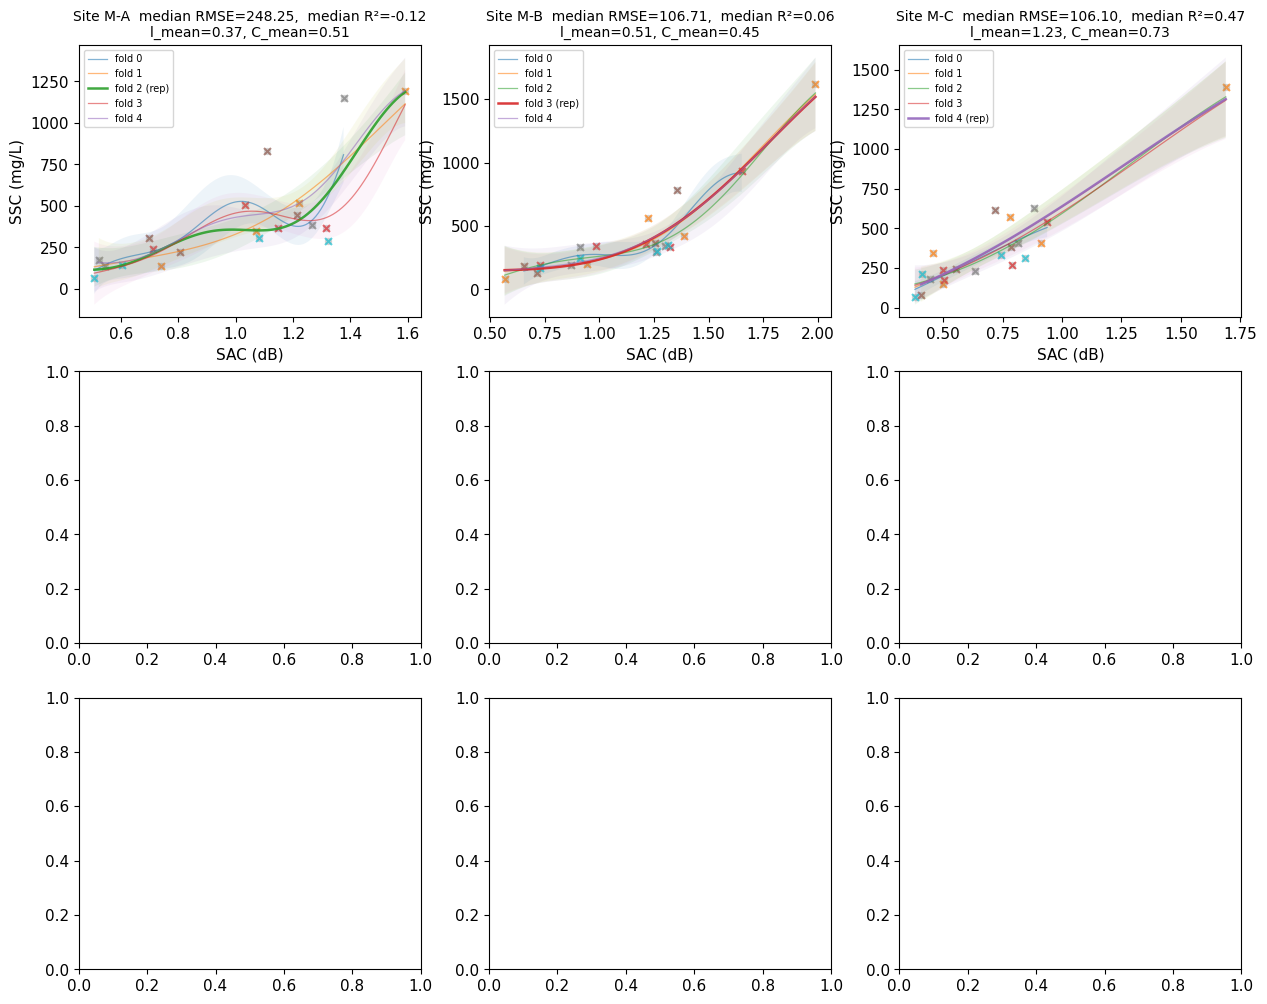

In [70]:
n_rows, n_cols, figsize = subplot_grid(len(site_ids), max_cols=3, panel_w=5, panel_h=4)
fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize, squeeze=False)
axes = axes.flatten()

for ax_idx, sid in enumerate(site_ids):
    ax = axes[ax_idx]
    folds = model_dictionary[sid]['folds']
    rep_idx = model_dictionary[sid]['representative_fold_idx']
    for fold_idx, f in folds.items():
        xg, yg, sg = f['pred']
        is_rep = (fold_idx == rep_idx)
        lw = 1.8 if is_rep else 0.9
        alpha = 0.9 if is_rep else 0.55
        label = f'fold {fold_idx}' + (' (rep)' if is_rep else '')
        ax.plot(xg, yg, linewidth=lw, alpha=alpha, label=label)
        ax.fill_between(xg, yg - 1.96 * sg, yg + 1.96 * sg, alpha=0.08)
        ax.scatter(f['x_test'], f['y_test'], s=25, marker='x', alpha=0.7)
    df_all = case_data[sid]['samples']
    ax.scatter(df_all['surrogate'], df_all['SSC'],
               color='lightgray', s=18, zorder=0)
    b = model_dictionary[sid]['baseline']
    ax.set_title(
        f"Site {site_label(sid)}  median RMSE={b['rmse_median']:.2f},  "
        f"median R\u00b2={b['r2_test_median']:.2f}\n"
        f"l_mean={b['length_scale_mean']:.2f}, C_mean={b['constant_mean']:.2f}",
        fontsize=10,
    )
    ax.set_xlabel(SURR_LABEL)
    ax.set_ylabel('SSC (mg/L)')
    ax.legend(fontsize=7, loc='best')
hide_unused_axes(axes, len(site_ids))
plt.suptitle(f'{CASE_STUDY}: per-fold baseline GP fits')
plt.tight_layout()
plt.show()

## 7. Frobenius-norm transferability diagnostic

Pairwise distance between baseline correlation matrices using each site's fold-averaged hyperparameters. Promoted from the SI to the main text per Reviewer 2 #1 and Reviewer 3 #1. Lower distance = better expected transfer.

In [ ]:
# Diagnostic: print fold-averaged hyperparameters per site so we can see
# whether they actually differ between sites. If two sites have identical
# (l, C) the Frobenius distance between them WILL be 0 by construction.
print('Per-site fold-averaged hyperparameters used in the Frobenius diagnostic:')
for sid in site_ids:
    hp = model_dictionary[sid]['baseline']['hyperparams_for_omp']
    print(f'  site {site_label(sid)}:  l = {hp["length_scale"]:.4f}   C = {hp["constant_value"]:.4f}')

# Replicates the diagnostic from the manuscript SI:
# For each (model_site, target_site) pair, evaluate model_site's kernel on the
# target_site's OWN scaled training-sample grid, normalize to a correlation matrix,
# and compute the *relative* Frobenius distance |A - B|_F / |B|_F where B is the
# target site's own kernel on its own grid.
site_ids = list(model_dictionary.keys())
fro_rel_matrix = np.zeros((len(site_ids), len(site_ids)))

def cov_to_cor(K):
    d = np.sqrt(np.diag(K))
    return K / np.outer(np.where(d > 0, d, 1), np.where(d > 0, d, 1))

# Precompute each target's scaled training grid (using the representative fold's
# training data, so this matches what would be used in OMP downstream).
target_grids = {}
for sid in site_ids:
    rep_idx = model_dictionary[sid]['representative_fold_idx']
    x_train = model_dictionary[sid]['folds'][rep_idx]['x_train']
    x_sort = np.sort(np.asarray(x_train, dtype=float))
    x_min, x_max = x_sort.min(), x_sort.max()
    rng = max(x_max - x_min, 1e-8)
    target_grids[sid] = (x_sort - x_min) / rng

for i, model_sid in enumerate(site_ids):
    hp_model = model_dictionary[model_sid]['baseline']['hyperparams_for_omp']
    for j, target_sid in enumerate(site_ids):
        grid = target_grids[target_sid]
        hp_target = model_dictionary[target_sid]['baseline']['hyperparams_for_omp']
        # Source kernel on target's grid
        K_src = build_correlation_matrix(grid, hp_model['length_scale'], hp_model['constant_value'])
        A = cov_to_cor(K_src)
        # Target's own kernel on target's grid (the reference)
        K_tgt = build_correlation_matrix(grid, hp_target['length_scale'], hp_target['constant_value'])
        B = cov_to_cor(K_tgt)
        ref_norm = np.linalg.norm(B, 'fro')
        fro_rel_matrix[i, j] = (
            np.linalg.norm(A - B, 'fro') / ref_norm if ref_norm > 1e-12 else np.nan
        )

labels = [site_label(s) for s in site_ids]
fig, ax = plt.subplots(figsize=(max(7, 0.9 * len(labels) + 4),
                                 max(6, 0.7 * len(labels) + 3)))
sns.heatmap(fro_rel_matrix, annot=True, fmt='.2f', cmap='mako',
            xticklabels=labels, yticklabels=labels,
            cbar_kws={'label': 'Relative Frobenius distance'}, ax=ax)
ax.set_xlabel('Target site'); ax.set_ylabel('Model source site')
ax.set_title(f'{CASE_STUDY}: Model-to-Site Correlation Matrix Distance (Frobenius Norm)')
plt.tight_layout()
plt.show()

## 8. Variance reduction utility (elbow plot)

How quickly does additional sampling reduce GP posterior variance, given an idealized uniformly-spaced surrogate range and each site's transferred kernel?

In [ ]:
n_eval = 25
n_rows, n_cols, figsize = subplot_grid(len(site_ids), max_cols=3, panel_w=4.8, panel_h=3.2)
fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize, squeeze=False)
axes = axes.flatten()

for i, sid in enumerate(site_ids):
    ax = axes[i]
    for j, model_sid in enumerate(site_ids):
        hp = model_dictionary[model_sid]['baseline']['hyperparams_for_omp']
        grid = np.linspace(0, 1, 60)
        K = build_correlation_matrix(grid, hp['length_scale'], hp['constant_value'])
        _, util = omp_variance_reduction(K, n_eval)
        ax.plot(range(1, len(util) + 1), util,
                marker=MARKERS[j % len(MARKERS)],
                color=COLORS[j % len(COLORS)],
                label=f'kernel from {site_label(model_sid)}',
                markersize=5, linewidth=1)
    ax.set_title(f'Site {site_label(sid)}')
    ax.set_xlabel('Samples selected')
    ax.set_ylabel('Variance reduction utility')
    ax.set_ylim(-0.05, 1.05)
    if i == 0:
        ax.legend(fontsize=7, loc='lower right')
hide_unused_axes(axes, len(site_ids))
plt.suptitle(f'{CASE_STUDY}: variance reduction elbow plots')
plt.tight_layout()
plt.show()

## 9. OMP static vs. stratified random vs. active learning

All three strategies are evaluated against the same held-out test set (the held-out fold of the representative fold, used for plotting only — performance metrics are still aggregated across folds where applicable). Random selection uses the proportional-stratified-bin sampler for both case studies.

In [ ]:
def gp_metrics_on_test(x_sel, y_sel, x_test, y_test):
    """Train a GP on selected samples and evaluate RMSE / nRMSE / R^2 on a fixed test set."""
    nan_out = {'rmse': np.nan, 'nrmse': np.nan, 'r2': np.nan}
    if len(x_sel) < 2 or np.ptp(x_sel) < 1e-8 or np.ptp(y_sel) < 1e-8:
        return nan_out
    try:
        _, _, scores = fit_gp(x_sel, y_sel, x_test, y_test)
    except Exception:
        return nan_out
    return {
        'rmse':  scores.get('rmse',    np.nan),
        'nrmse': scores.get('nrmse',   np.nan),
        'r2':    scores.get('r2_test', np.nan),
    }

comparison = {}
METRIC_KEYS = ['rmse', 'nrmse', 'r2']

for sid in site_ids:
    samples = case_data[sid]['samples']
    x_all = samples['surrogate'].to_numpy()
    y_all = samples['SSC'].to_numpy()
    n = len(x_all)
    if n < 5:
        continue
    rep_fold_idx = model_dictionary[sid]['representative_fold_idx']
    fold = model_dictionary[sid]['folds'][rep_fold_idx]
    x_test, y_test = fold['x_test'], fold['y_test']
    # Build candidate pool from non-test indices
    train_indices = sorted(set(range(n)) - set(np.where(
        np.isin(x_all, x_test) & np.isin(y_all, y_test))[0].tolist()))
    x_pool, y_pool = x_all[train_indices], y_all[train_indices]

    n_max = min(OMP_MAX_N, len(x_pool))
    n_grid = list(range(2, n_max + 1))

    def _curve(order_indices):
        """Walk the selection order and return per-n metric curves."""
        out = {m: [] for m in METRIC_KEYS}
        for nn in n_grid:
            sel = order_indices[:nn]
            mvals = gp_metrics_on_test(x_pool[sel], y_pool[sel], x_test, y_test)
            for m in METRIC_KEYS:
                out[m].append(mvals[m])
        return out

    # ----- OMP static (transfer from each source site) -----
    omp_static = {}
    for model_sid in site_ids:
        hp = model_dictionary[model_sid]['baseline']['hyperparams_for_omp']
        x_min, x_max = x_pool.min(), x_pool.max()
        rng = max(x_max - x_min, 1e-8)
        xs = (x_pool - x_min) / rng
        K = build_correlation_matrix(xs, hp['length_scale'], hp['constant_value'])
        order, _ = omp_variance_reduction(K, n_max)
        omp_static[model_sid] = {'order': order, 'curves': _curve(order)}

    # ----- Active learning (use each source as init) -----
    omp_active = {}
    for model_sid in site_ids:
        hp = model_dictionary[model_sid]['baseline']['hyperparams_for_omp']
        order = active_learning_select(x_pool, y_pool,
                                       hp['constant_value'], hp['length_scale'],
                                       n_total=n_max, batch=ACTIVE_BATCH)
        omp_active[model_sid] = {'order': order, 'curves': _curve(order)}

    # ----- Stratified random benchmark (median + IQR envelope) -----
    rand_metrics = {m: {nn: [] for nn in n_grid} for m in METRIC_KEYS}
    for perm in range(N_RAND_PERMS):
        rng_perm = np.random.default_rng(RANDOM_SEED + perm)
        for nn in n_grid:
            idx = proportional_stratified_sample(x_pool, nn, N_STRAT_BINS, rng_perm)
            mvals = gp_metrics_on_test(x_pool[idx], y_pool[idx], x_test, y_test)
            for m in METRIC_KEYS:
                rand_metrics[m][nn].append(mvals[m])
    rand_summary = {'n': n_grid}
    for m in METRIC_KEYS:
        rand_summary[f'{m}_median'] = [float(np.nanmedian(rand_metrics[m][nn])) for nn in n_grid]
        rand_summary[f'{m}_q25']    = [float(np.nanpercentile(rand_metrics[m][nn], 25)) for nn in n_grid]
        rand_summary[f'{m}_q75']    = [float(np.nanpercentile(rand_metrics[m][nn], 75)) for nn in n_grid]

    comparison[sid] = {
        'omp_static': omp_static,
        'omp_active': omp_active,
        'random':     rand_summary,
        'n_grid':     n_grid,
        'x_pool':     x_pool, 'y_pool': y_pool,
        'x_test':     x_test, 'y_test': y_test,
    }

print('Comparison complete for sites:', [site_label(s) for s in comparison.keys()])

In [ ]:
# Plot RMSE, nRMSE, and R^2 vs. number of samples per site (3 panels per site)
METRIC_LABELS = {
    'rmse':  'Test RMSE (mg/L)',
    'nrmse': 'Test nRMSE',
    'r2':    'Test R\u00b2',
}

n_sites = len(comparison)
if n_sites == 0:
    print('No sites had enough samples for the OMP comparison.')
else:
    fig, axes = plt.subplots(n_sites, 3, figsize=(15, 3.2 * n_sites),
                              squeeze=False, sharex='col')
    for row_idx, (sid, comp) in enumerate(comparison.items()):
        ng = comp['random']['n']
        for col_idx, m in enumerate(METRIC_KEYS):
            ax = axes[row_idx, col_idx]
            ax.fill_between(ng, comp['random'][f'{m}_q25'], comp['random'][f'{m}_q75'],
                            color='gray', alpha=0.25, label='Stratified random IQR')
            ax.plot(ng, comp['random'][f'{m}_median'], color='black', marker='o',
                    markersize=4, label='Stratified random median')
            for j, model_sid in enumerate(comp['omp_static'].keys()):
                curves = comp['omp_static'][model_sid]['curves']
                ax.plot(ng, curves[m], linestyle='--', alpha=0.7,
                        color=COLORS[j % len(COLORS)],
                        label=f'OMP static (from {site_label(model_sid)})')
            for j, model_sid in enumerate(comp['omp_active'].keys()):
                curves = comp['omp_active'][model_sid]['curves']
                ax.plot(ng, curves[m], linestyle=':', alpha=0.7,
                        color=COLORS[j % len(COLORS)],
                        label=f'OMP active (from {site_label(model_sid)})')
            ax.set_xlabel('Number of training samples')
            ax.set_ylabel(METRIC_LABELS[m])
            if col_idx == 0:
                ax.set_title(f'Site {site_label(sid)}  ({METRIC_LABELS[m]})', loc='left')
            else:
                ax.set_title(METRIC_LABELS[m], loc='left')
            if row_idx == 0 and col_idx == 2:
                ax.legend(fontsize=6, ncol=2, loc='lower right')
            if m == 'r2':
                ax.set_ylim(top=1.05)
    plt.suptitle(f'{CASE_STUDY}: OMP vs stratified random vs active learning '
                 f'(median of {N_RAND_PERMS} random perms; IQR shaded)')
    plt.tight_layout()
    plt.show()

## 10. Time-series prediction with initial-window training

Only applicable to case studies that include a continuous surrogate stream. Restricts the available samples to those collected during the first `TRAIN_MONTHS` months of the record, runs OMP using each source site's averaged hyperparameters, trains the GP on the OMP-selected subset, and predicts on the full continuous time series.

In [ ]:
def time_series_prediction(target_sid, model_sid, n_train=TS_N_SAMPLES,
                            train_months=TRAIN_MONTHS):
    case = case_data[target_sid]
    if case['continuous'] is None or len(case['continuous']) == 0:
        return None
    samples = case['samples'].copy()
    if 'datetime' not in samples.columns or samples['datetime'].isna().all():
        return None
    samples = samples.dropna(subset=['datetime', 'surrogate', 'SSC'])
    samples = samples.sort_values('datetime').reset_index(drop=True)
    start = samples['datetime'].min()
    cutoff = start + pd.DateOffset(months=train_months)
    mask = samples['datetime'] <= cutoff
    subset = samples[mask].copy()
    if len(subset) < n_train:
        return None

    # OMP-select from initial window using model_sid's averaged hyperparameters
    hp = model_dictionary[model_sid]['baseline']['hyperparams_for_omp']
    x_sub = subset['surrogate'].to_numpy()
    x_min, x_max = x_sub.min(), x_sub.max()
    rng_ = max(x_max - x_min, 1e-8)
    K = build_correlation_matrix((x_sub - x_min) / rng_, hp['length_scale'], hp['constant_value'])
    order, _ = omp_variance_reduction(K, n_train)
    sel = order[:n_train]
    x_train = x_sub[sel]
    y_train = subset['SSC'].to_numpy()[sel]
    dates_train = subset['datetime'].to_numpy()[sel]

    # Predict on full continuous stream
    cont = case['continuous'].sort_values('datetime').reset_index(drop=True)
    x_full = cont['surrogate'].to_numpy()
    dates_full = cont['datetime'].to_numpy()
    gpr, (xg, yg, sg), scores = fit_gp(x_train, y_train)
    x_min_t, x_rng_t = scores['x_scale']
    y_min_t, y_rng_t = scores['y_scale']
    Xc = ((x_full - x_min_t) / x_rng_t).reshape(-1, 1)
    ypred_scaled, std_scaled = gpr.predict(Xc, return_std=True)
    ypred = ypred_scaled.flatten() * y_rng_t + y_min_t
    std = std_scaled.flatten() * y_rng_t
    # Interpolate predictions onto the grab-sample timestamps for evaluation
    y_obs = samples['SSC'].to_numpy()
    obs_t_int = samples['datetime'].astype(np.int64).to_numpy()
    full_t_int = dates_full.astype('datetime64[ns]').astype(np.int64)
    y_hat_at_obs = np.interp(obs_t_int, full_t_int, ypred)
    residuals = y_obs - y_hat_at_obs
    rmse_grab = float(np.sqrt(np.mean(residuals ** 2)))
    y_rng = float(y_obs.max() - y_obs.min()) if len(y_obs) > 1 else np.nan
    nrmse_grab = rmse_grab / y_rng if y_rng and y_rng > 0 else np.nan
    ss_res = float(np.sum(residuals ** 2))
    ss_tot = float(np.sum((y_obs - np.mean(y_obs)) ** 2)) if len(y_obs) > 1 else 0.0
    r2_grab = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    return {
        'dates_full':  dates_full, 'ypred':       ypred, 'std':         std,
        'dates_train': dates_train, 'x_train':     x_train, 'y_train':     y_train,
        'samples_obs': samples,
        'rmse_on_grab':  rmse_grab,
        'nrmse_on_grab': nrmse_grab,
        'r2_on_grab':    r2_grab,
    }

ts_results = {}
for target in site_ids:
    for source in site_ids:
        out = time_series_prediction(target, source)
        if out is not None:
            ts_results[(target, source)] = out

if not ts_results:
    print('No continuous time-series data for this case study. Skipping time-series plot.')
else:
    # One panel per (target, source) pair, arranged as targets in rows x sources in cols
    targets = sorted({k[0] for k in ts_results.keys()})
    sources = sorted({k[1] for k in ts_results.keys()})
    n_rows = len(targets); n_cols = len(sources)
    fig, axes = plt.subplots(n_rows, n_cols,
                              figsize=(6 * n_cols, 3.5 * n_rows),
                              squeeze=False, sharex=True, sharey='row')
    for r, target in enumerate(targets):
        obs = case_data[target]['samples']
        for c, source in enumerate(sources):
            ax = axes[r, c]
            res = ts_results.get((target, source))
            if res is None:
                ax.set_visible(False)
                continue
            # 95% confidence band
            ax.fill_between(res['dates_full'],
                            res['ypred'] - 1.96 * res['std'],
                            res['ypred'] + 1.96 * res['std'],
                            alpha=0.2, color='#3D7AAB', label='95% CI')
            ax.plot(res['dates_full'], res['ypred'],
                    color='#1F4E79', linewidth=1.2, label='GP prediction')
            # All observed grab samples in white-faced circles
            ax.scatter(obs['datetime'], obs['SSC'],
                       facecolors='none', edgecolors='black', s=30, linewidths=0.8,
                       zorder=4, label='Observed SSC')
            # OMP-selected training samples highlighted in red stars
            ax.scatter(res['dates_train'], res['y_train'],
                       color='#D62728', marker='*', s=120,
                       edgecolors='black', linewidths=0.6,
                       zorder=6, label=f'OMP training (n={len(res["y_train"])})')
            ax.set_title(
                f'Target {site_label(target)}  |  source {site_label(source)}\n'
                f'RMSE={res["rmse_on_grab"]:.1f}  '
                f'nRMSE={res["nrmse_on_grab"]:.2f}  '
                f'R\u00b2={res["r2_on_grab"]:.2f}',
                fontsize=10,
            )
            if c == 0:
                ax.set_ylabel('SSC (mg/L)')
            if r == n_rows - 1:
                ax.set_xlabel('Date')
                for label in ax.get_xticklabels():
                    label.set_rotation(30)
                    label.set_horizontalalignment('right')
            if r == 0 and c == 0:
                ax.legend(fontsize=8, loc='upper right')
    plt.suptitle(
        f'{CASE_STUDY}: time-series prediction with initial-window training '
        f'(n_train={TS_N_SAMPLES}, first {TRAIN_MONTHS} months)',
        fontsize=12, y=1.01,
    )
    plt.tight_layout()
    plt.show()

## 11. Calibration analysis (Reviewer 3 #11)

Per-site 95% interval coverage and Spearman rank correlation between predicted standard deviation and absolute residual on held-out folds. Aggregated across folds.

In [ ]:
calib_rows = []
for sid in site_ids:
    b = model_dictionary[sid]['baseline']
    calib_rows.append({
        'site': site_label(sid),
        'coverage_95': round(b['coverage_95_median'], 3),
        'unc_err_rho': round(b['unc_err_rho_median'], 3),
    })
calib_df = pd.DataFrame(calib_rows)
calib_df

In [ ]:
# Diagnostic scatter: predicted std vs absolute residual, pooled across folds
n_rows, n_cols, figsize = subplot_grid(len(site_ids), max_cols=3, panel_w=4.5, panel_h=3.2)
fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize, squeeze=False)
axes = axes.flatten()
for i, sid in enumerate(site_ids):
    ax = axes[i]
    stds, residuals = [], []
    for f in model_dictionary[sid]['folds'].values():
        if 'std_test' not in f['scores'] or 'ypred_test' not in f['scores']:
            continue
        stds.extend(np.asarray(f['scores']['std_test']).tolist())
        residuals.extend(np.abs(np.asarray(f['y_test']) -
                                  np.asarray(f['scores']['ypred_test'])).tolist())
    if len(stds) < 3:
        ax.set_visible(False); continue
    stds = np.array(stds); residuals = np.array(residuals)
    ax.scatter(stds, residuals, alpha=0.6)
    ax.set_xlabel('Predicted std')
    ax.set_ylabel('|residual|')
    if np.std(stds) > 1e-12:
        rho, _ = spearmanr(stds, residuals)
    else:
        rho = np.nan
    ax.set_title(f'Site {site_label(sid)}  (\u03c1={rho:.2f})')
hide_unused_axes(axes, len(site_ids))
plt.suptitle(f'{CASE_STUDY}: predicted std vs. absolute residual')
plt.tight_layout()
plt.show()

## 12. Process-relevance analysis (Reviewer 3 #6/#8)

Do OMP picks preferentially capture upper-SSC-quartile / upper-surrogate-quartile conditions vs. matched bootstrapped random selections? Done per site with N_top = 6 and 10.

In [ ]:
process_rows = []
for sid in site_ids:
    samples = case_data[sid]['samples']
    x_all = samples['surrogate'].to_numpy()
    y_all = samples['SSC'].to_numpy()
    if len(x_all) < 6:
        continue
    hp = model_dictionary[sid]['baseline']['hyperparams_for_omp']
    x_min, x_max = x_all.min(), x_all.max()
    rng_ = max(x_max - x_min, 1e-8)
    xs = (x_all - x_min) / rng_
    K = build_correlation_matrix(xs, hp['length_scale'], hp['constant_value'])
    order, _ = omp_variance_reduction(K, min(OMP_MAX_N, len(x_all)))
    for n_top in (6, 10):
        if n_top > len(x_all):
            continue
        s = omp_vs_random_summary(x_all, y_all, order, n_top=n_top, n_random=200)
        s['site'] = site_label(sid)
        process_rows.append(s)
if not process_rows:
    print('No site had enough samples for the process-relevance analysis.')
    process_df = pd.DataFrame()
else:
    process_df = pd.DataFrame(process_rows)
    cols = ['site', 'n_top', 'omp_frac_top25_ssc', 'rand_frac_top25_ssc_mean',
            'rand_frac_top25_ssc_p95', 'omp_frac_top25_surr',
            'rand_frac_top25_surr_mean', 'rand_frac_top25_surr_p95']
    process_df = process_df[cols].round(3)
process_df

In [ ]:
# Visual: overlay OMP top-10 picks vs. one random draw of size 10
n_rows, n_cols, figsize = subplot_grid(len(site_ids), max_cols=3, panel_w=4.5, panel_h=3.2)
fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize, squeeze=False)
axes = axes.flatten()
rng_ = np.random.default_rng(RANDOM_SEED)
for i, sid in enumerate(site_ids):
    ax = axes[i]
    samples = case_data[sid]['samples']
    x_all = samples['surrogate'].to_numpy()
    y_all = samples['SSC'].to_numpy()
    if len(x_all) < 6:
        ax.set_visible(False); continue
    hp = model_dictionary[sid]['baseline']['hyperparams_for_omp']
    x_min, x_max = x_all.min(), x_all.max()
    rng__ = max(x_max - x_min, 1e-8)
    K = build_correlation_matrix((x_all - x_min) / rng__,
                                  hp['length_scale'], hp['constant_value'])
    order, _ = omp_variance_reduction(K, min(10, len(x_all)))
    n_top = min(10, len(x_all))
    omp_idx = order[:n_top]
    rand_idx = rng_.choice(len(x_all), size=n_top, replace=False)
    ax.scatter(x_all, y_all, color='lightgray', s=25, label='All samples')
    ax.scatter(x_all[rand_idx], y_all[rand_idx],
               facecolors='none', edgecolors='C1', s=80, label=f'Random top-{n_top}')
    ax.scatter(x_all[omp_idx], y_all[omp_idx],
               color='C3', s=40, label=f'OMP top-{n_top}', zorder=5)
    ax.set_xlabel(SURR_LABEL); ax.set_ylabel('SSC (mg/L)')
    ax.set_title(f'Site {site_label(sid)}')
    if i == 0:
        ax.legend(fontsize=8)
hide_unused_axes(axes, len(site_ids))
plt.suptitle(f'{CASE_STUDY}: OMP vs random top picks (process-relevance)')
plt.tight_layout()
plt.show()

## Done

All the analyses needed for the response-to-reviewers are in this notebook. To rerun for the other case study, change `CASE_STUDY` at the top and re-run all cells.

**Outputs to drop into the manuscript / SI**:
- `summary_df` (§6): fold-aggregated per-site metrics (RMSE, nRMSE, R², coverage, ρ, kernel hyperparameters).
- Frobenius heatmap (§7): the transferability diagnostic.
- Variance reduction elbow figure (§8).
- OMP vs. stratified random vs. active learning per-site figure (§9).
- Time-series prediction figure (§10) — MN only.
- `calib_df` (§11) + predicted-std-vs-residual scatters.
- `process_df` (§12) + OMP-vs-random overlay scatter.